# Workforce-as-a-Service: Comprehensive Forecasting Pipeline

**Company:** JITWO Inc.  
**Analyst:** **Trixie Ocampo** [Senior Manager - Applied Scientist]  


**Dataset:** Capstone Dataset   
**Objective:** End-to-end forecasting pipeline for **Offered Calls** and **Required Staffing (FTE)** across Single-Centre and multi-region Network views.

---

## Pipeline Architecture

```
Google Drive Ingestion
        │
        ▼
  Data Loading & Validation
        │
        ▼
  Exploratory Data Analysis (EDA)
        │
        ▼
  Feature Engineering
  (Erlang-C Staffing, Lag/Rolling Features, WFM Metrics)
        │
        ▼
  Forecasting Models
  ├── **Prophet** (Baseline)
  ├── **XGBoost** w/ WFM Features
  └── **LightGBM** (Network-level)
        │
        ▼
  Evaluation & Diagnostics
        │
        ▼
  Staffing Recommendations
  (Erlang-C Required FTE + Headcount Planning)
        │
        ▼
  Export & Reporting
```

---

### Data Dictionary

**Single Centre Sheet**
| Column | Description |
|---|---|
| Date | Daily date (Q4 2024, 90 days) |
| Offered Calls | Inbound contacts offered to the center (daily) |
| AHT (s) | Average Handle Time in seconds |
| Shrinkage % | % of scheduled time not productive (blended) |
| Attrition % (weekly) | Weekly rolling attrition rate |
| Holidays | 1 if US/CA holiday, 0 otherwise |
| MarketingEvents | 1 if promo/marketing event flag |
| ActualStaff (FTE) | Estimated productive FTE on the day |
| ServiceLevel % | Achieved service level % |

**Network Sheet** — Same metrics, segmented by Region (US, India, Philippines) × Channel (Voice, Email).

## N. Environment Setup & Google Drive Mount

In [ ]:
!pip install -q prophet lightgbm xgboost openpyxl shap plotly

In [ ]:
DATASET_PATH = '/content/Capstone Dataset.xlsx'

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

import xgboost as xgb
import lightgbm as lgb
from prophet import Prophet
import shap

import math
from itertools import product as itertools_product
from IPython.display import display, HTML

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (14, 5)})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Environment ready.")

Environment ready.



## I. Data Ingestion & Validation

### Ingestion

In [ ]:
sc_raw = pd.read_excel(DATASET_PATH, sheet_name='Single Centre')
net_raw = pd.read_excel(DATASET_PATH, sheet_name='Network')

print("Single Centre shape:", sc_raw.shape)
print("Network shape:      ", net_raw.shape)
display(sc_raw.head(3))
display(net_raw.head(3))

Single Centre shape: (90, 9)
Network shape:       (540, 10)


,Date,Offered Calls,AHT (s),Shrinkage %,Attrition % (weekly),Holidays,MarketingEvents,ActualStaff (FTE),ServiceLevel %
0,2024-10-01,11653,307,29.54,2.09,0,0,215.8,78.8
1,2024-10-02,10694,309,27.69,2.09,0,0,207.6,82.1
2,2024-10-03,10986,288,27.51,2.09,0,0,182.8,78.1


,Date,Region,Channel,Offered,AHT (s),Shrinkage %,Attrition % (weekly),HolidayRegion,StaffedFTE,SLA %
0,2024-10-01,US,Voice,4370,330,27.23,2.18,0,86.7,80.2
1,2024-10-01,US,Email,1574,409,27.16,2.03,0,36.5,77.4
2,2024-10-01,India,Voice,3316,302,31.15,2.32,0,66.4,82.4


### Date Parsing

In [ ]:
def parse_excel_date(series):
    """Handle Excel serial dates (float) or real datetime objects."""
    if pd.api.types.is_float_dtype(series) or pd.api.types.is_integer_dtype(series):
        return pd.to_datetime(series, unit='D', origin='1899-12-30')
    return pd.to_datetime(series)

sc_raw['Date'] = parse_excel_date(sc_raw['Date'])
net_raw['Date'] = parse_excel_date(net_raw['Date'])

print("Single Centre date range:", sc_raw['Date'].min().date(), '→', sc_raw['Date'].max().date())
print("Network date range:      ", net_raw['Date'].min().date(), '→', net_raw['Date'].max().date())

Single Centre date range: 2024-10-01 → 2024-12-29
Network date range:       2024-10-01 → 2024-12-29


### Mini Data Quality Report

In [ ]:
def data_quality_report(df, name):
    print(f"\n{'='*60}")
    print(f"  {name} — Data Quality Report")
    print(f"{'='*60}")
    print(f"  Rows: {len(df):,}  |  Columns: {df.shape[1]}")

    null_pct = (df.isnull().sum() / len(df) * 100).round(2)
    dup_rows = df.duplicated().sum()

    quality_df = pd.DataFrame({
        'dtype': df.dtypes,
        'null_count': df.isnull().sum(),
        'null_%': null_pct,
        'unique': df.nunique()
    })
    display(quality_df)
    print(f"  Duplicate rows: {dup_rows}")
    return quality_df

_ = data_quality_report(sc_raw, 'Single Centre')
_ = data_quality_report(net_raw, 'Network')


  Single Centre — Data Quality Report
  Rows: 90  |  Columns: 9


,dtype,null_count,null_%,unique
Date,datetime64[ns],0,0.0,90
Offered Calls,int64,0,0.0,89
AHT (s),int64,0,0.0,51
Shrinkage %,float64,0,0.0,90
Attrition % (weekly),float64,0,0.0,13
Holidays,int64,0,0.0,2
MarketingEvents,int64,0,0.0,2
ActualStaff (FTE),float64,0,0.0,88
ServiceLevel %,float64,0,0.0,29


  Duplicate rows: 0

  Network — Data Quality Report
  Rows: 540  |  Columns: 10


,dtype,null_count,null_%,unique
Date,datetime64[ns],0,0.0,90
Region,object,0,0.0,3
Channel,object,0,0.0,2
Offered,int64,0,0.0,481
AHT (s),int64,0,0.0,119
Shrinkage %,float64,0,0.0,401
Attrition % (weekly),float64,0,0.0,106
HolidayRegion,int64,0,0.0,2
StaffedFTE,float64,0,0.0,362
SLA %,float64,0,0.0,62


  Duplicate rows: 0


### Data Cleaning

In [ ]:
def clean_cols(df):
    df = df.copy()
    df.columns = (
        df.columns.str.strip()
          .str.replace(r'[\s\.\(\)%]+', '_', regex=True)
          .str.replace('__', '_', regex=False)
          .str.strip('_')
          .str.lower()
    )
    return df

sc = clean_cols(sc_raw).sort_values('date').reset_index(drop=True)
net = clean_cols(net_raw).sort_values(['date','region','channel']).reset_index(drop=True)

print("Single Centre columns:", sc.columns.tolist())
print("Network columns:      ", net.columns.tolist())

Single Centre columns: ['date', 'offered_calls', 'aht_s', 'shrinkage', 'attrition_weekly', 'holidays', 'marketingevents', 'actualstaff_fte', 'servicelevel']
Network columns:       ['date', 'region', 'channel', 'offered', 'aht_s', 'shrinkage', 'attrition_weekly', 'holidayregion', 'staffedfte', 'sla']



## II. Exploratory Data Analysis (EDA)

### Descriptive Stats

In [ ]:
print("\n── Single Centre Descriptive Statistics ──")
display(sc.describe().round(2))


── Single Centre Descriptive Statistics ──


,date,offered_calls,aht_s,shrinkage,attrition_weekly,holidays,marketingevents,actualstaff_fte,servicelevel
count,90,90.00,90.00,90.00,90.00,90.00,90.00,90.00,90.00
mean,2024-11-14 12:00:00,10916.30,296.78,29.18,1.83,0.07,0.04,200.95,80.08
min,2024-10-01 00:00:00,8413.00,263.00,26.92,1.51,0.00,0.00,144.80,78.10
25%,2024-10-23 06:00:00,9904.75,278.00,28.18,1.72,0.00,0.00,173.50,79.50
50%,2024-11-14 12:00:00,10799.00,297.00,29.17,1.82,0.00,0.00,194.90,80.05
75%,2024-12-06 18:00:00,11657.50,309.00,29.93,1.93,0.00,0.00,219.85,80.60
max,2024-12-29 00:00:00,14912.00,351.00,32.25,2.12,1.00,1.00,313.60,82.10
std,NaN,1305.65,20.74,1.27,0.17,0.25,0.21,36.73,0.78


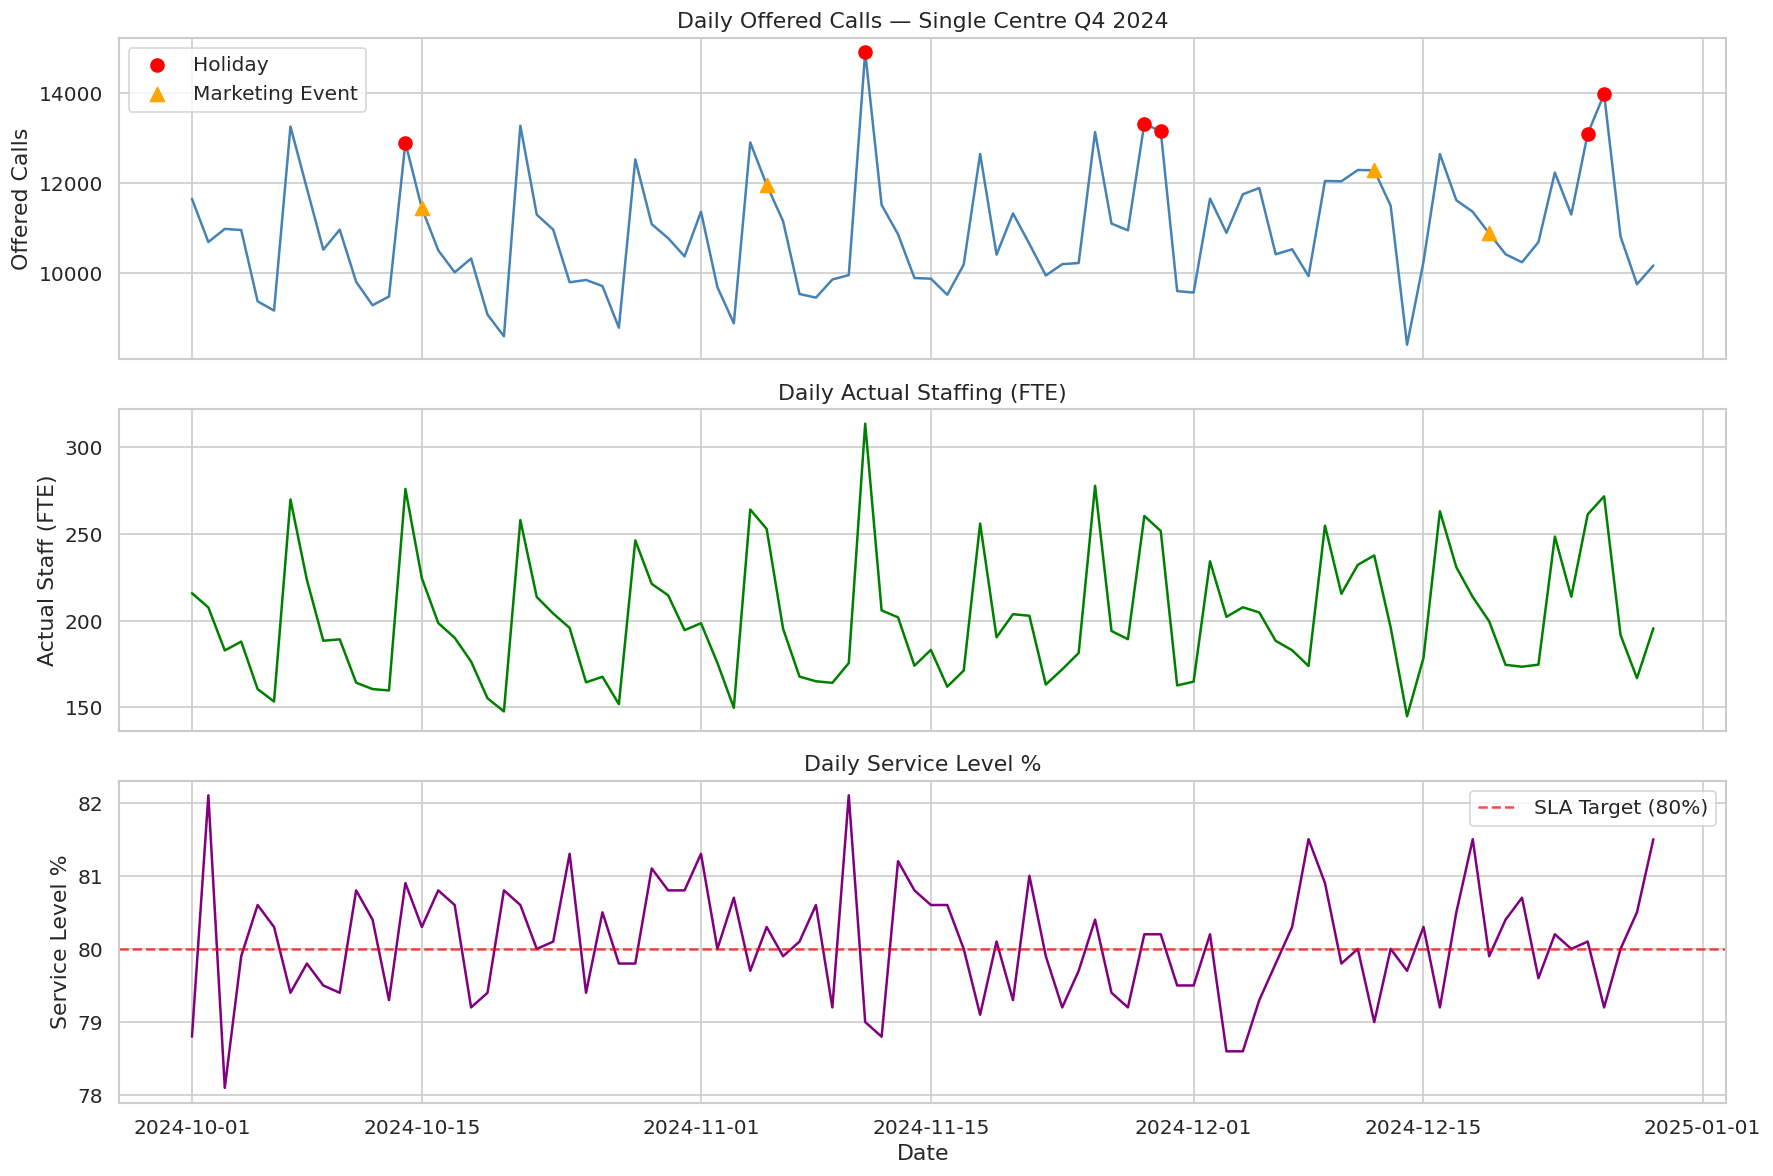

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

axes[0].plot(sc['date'], sc['offered_calls'], color='steelblue', linewidth=1.5)
axes[0].scatter(sc.loc[sc['holidays']==1,'date'], sc.loc[sc['holidays']==1,'offered_calls'],
                color='red', zorder=5, label='Holiday', s=60)
axes[0].scatter(sc.loc[sc['marketingevents']==1,'date'], sc.loc[sc['marketingevents']==1,'offered_calls'],
                color='orange', zorder=5, label='Marketing Event', marker='^', s=70)
axes[0].set_ylabel('Offered Calls')
axes[0].set_title('Daily Offered Calls — Single Centre Q4 2024')
axes[0].legend()

axes[1].plot(sc['date'], sc['actualstaff_fte'], color='green', linewidth=1.5)
axes[1].set_ylabel('Actual Staff (FTE)')
axes[1].set_title('Daily Actual Staffing (FTE)')

axes[2].plot(sc['date'], sc['servicelevel'], color='purple', linewidth=1.5)
axes[2].axhline(80, color='red', linestyle='--', alpha=0.7, label='SLA Target (80%)')
axes[2].set_ylabel('Service Level %')
axes[2].set_title('Daily Service Level %')
axes[2].set_xlabel('Date')
axes[2].legend()

plt.tight_layout()
plt.show()

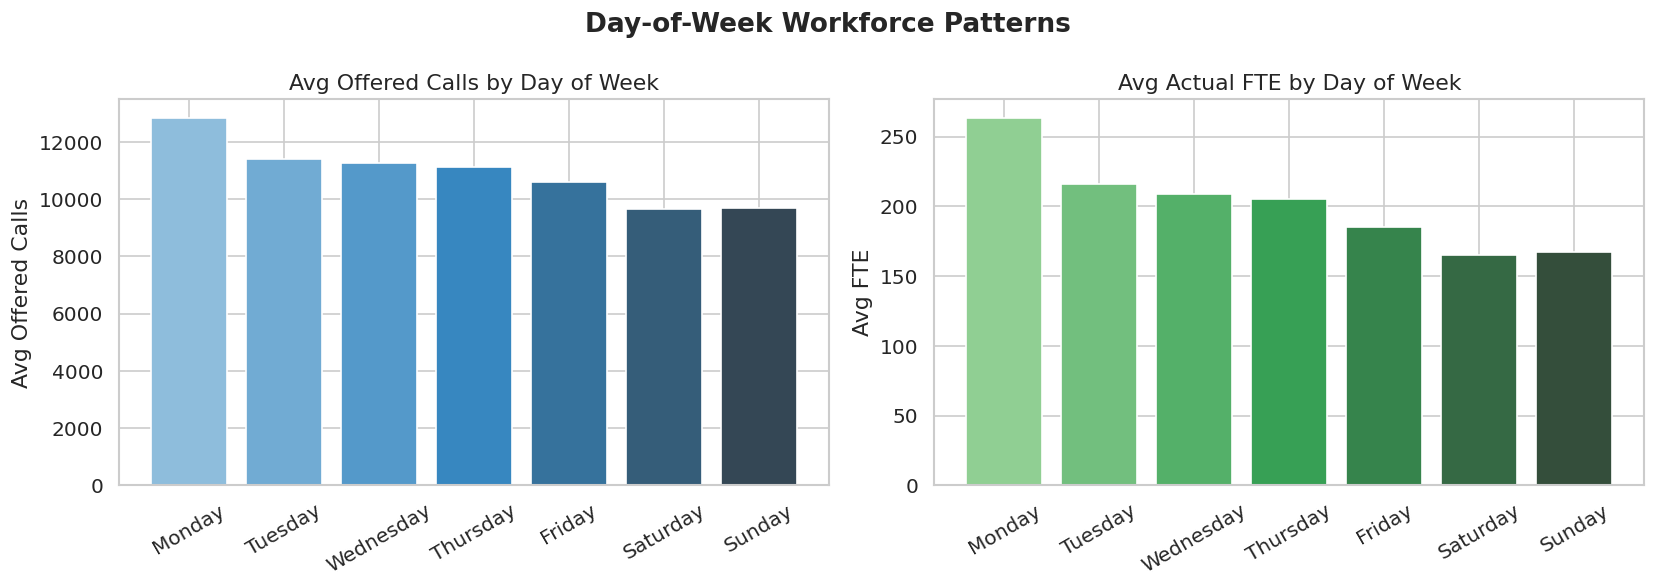

In [ ]:
sc['dow'] = sc['date'].dt.day_name()
DOW_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dow_calls = sc.groupby('dow')['offered_calls'].mean().reindex(DOW_ORDER)
dow_fte   = sc.groupby('dow')['actualstaff_fte'].mean().reindex(DOW_ORDER)

axes[0].bar(DOW_ORDER, dow_calls, color=sns.color_palette('Blues_d', 7))
axes[0].set_title('Avg Offered Calls by Day of Week')
axes[0].set_ylabel('Avg Offered Calls')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(DOW_ORDER, dow_fte, color=sns.color_palette('Greens_d', 7))
axes[1].set_title('Avg Actual FTE by Day of Week')
axes[1].set_ylabel('Avg FTE')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Day-of-Week Workforce Patterns', fontweight='bold')
plt.tight_layout()
plt.show()

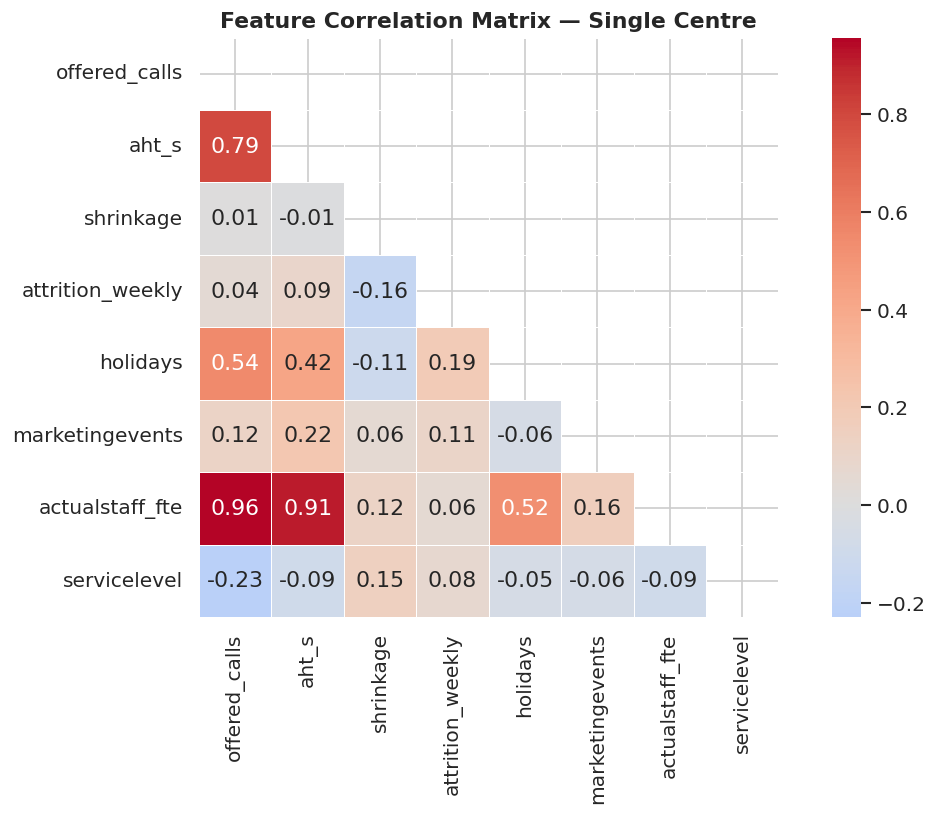

In [ ]:
numeric_cols = sc.select_dtypes(include=np.number).columns.tolist()
corr = sc[numeric_cols].corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True)
plt.title('Feature Correlation Matrix — Single Centre', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
net_agg = net.groupby(['date','region','channel'])['offered'].sum().reset_index()

fig = px.line(
    net_agg, x='date', y='offered', color='region',
    facet_row='channel', line_dash='region',
    title='Network: Daily Offered Contacts by Region & Channel',
    labels={'offered': 'Offered Contacts', 'date': 'Date'},
    height=600
)
fig.update_layout(hovermode='x unified')
fig.show()

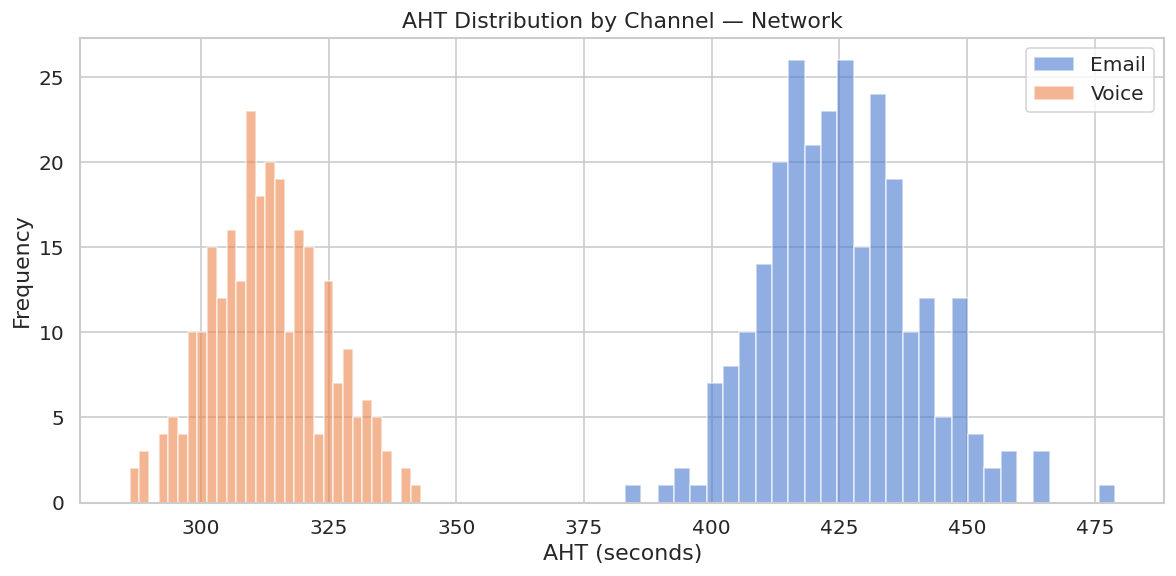

         count   mean   std    min    25%    50%    75%    max
channel                                                       
Email    270.0  425.4  14.7  383.0  415.0  425.0  435.0  479.0
Voice    270.0  313.0  11.2  286.0  305.0  312.5  321.0  343.0


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
for channel, grp in net.groupby('channel'):
    grp['aht_s'].plot.hist(ax=ax, alpha=0.6, bins=30, label=channel)
ax.set_xlabel('AHT (seconds)')
ax.set_title('AHT Distribution by Channel — Network')
ax.legend()
plt.tight_layout()
plt.show()

print(net.groupby('channel')['aht_s'].describe().round(1))


## III. Feature Engineering

I built three layers of features:
1. **Calendar features** — Day-of-week, week-of-year, month, is_weekend, etc.
2. **Lag & rolling features** — Autocorrelation-aware lags (7d, 14d), rolling means/stds.
3. **WFM-derived features** — Erlang-C required FTE, workload (Erlangs), utilisation.

### Erlang-C Staffing Model

In [ ]:
def erlang_c_asa(traffic_intensity, n_agents, target_asa_s=20, interval_s=86400):
    """
    Compute Erlang-C probability of waiting (Pw) and estimated ASA.

    Args:
        traffic_intensity : Erlangs (A = call_rate × AHT)
        n_agents          : Number of agents
        target_asa_s      : Target average speed of answer (seconds)
        interval_s        : Interval length in seconds (default = 1 day)
    Returns:
        pw  : Probability of queuing
        asa : Estimated average speed of answer (seconds)
    """
    A = traffic_intensity
    N = n_agents

    if N <= A or A <= 0 or N <= 0:
        return 1.0, float('inf')

    # Erlang-C formula
    try:
        # Numerator: A^N / N! * (N / (N-A))
        sum_term = sum((A**k) / math.factorial(k) for k in range(int(N)))
        erlang_term = (A**N / math.factorial(int(N))) * (N / (N - A))
        pw = erlang_term / (sum_term + erlang_term)
    except (OverflowError, ValueError):
        pw = 1.0

    asa = (pw / (N - A)) if (N - A) > 0 else float('inf')
    return round(pw, 4), round(asa, 2)


def required_fte_erlang(
    offered_calls, aht_s, shrinkage_pct,
    target_sl=0.80, target_asa_s=20, max_agents=1000
):
    """
    Iterate N agents until SL target is met, then inflate by shrinkage.

    Returns:
        productive_fte  : Agents needed on phones
        scheduled_fte   : Agents to schedule (productive / (1 - shrinkage))
        erlangs         : Traffic intensity
        pw              : P(wait)
    """
    if offered_calls <= 0 or aht_s <= 0:
        return 0, 0, 0, 0

    erlangs = (offered_calls * aht_s) / 86400  # A = λ × h  (daily)
    shrink_factor = 1 - (shrinkage_pct / 100)

    # Start search at ceiling of Erlangs
    N = max(1, math.ceil(erlangs))
    for N in range(N, max_agents):
        pw, asa = erlang_c_asa(erlangs, N)
        # Service level ≈ 1 - Pw * exp(-(N-A) * target_asa / AHT)
        if N > erlangs:
            sl = 1 - pw * math.exp(-(N - erlangs) * target_asa_s / aht_s)
        else:
            sl = 0
        if sl >= target_sl:
            break

    productive_fte = N
    scheduled_fte  = productive_fte / shrink_factor if shrink_factor > 0 else productive_fte
    return round(productive_fte, 2), round(scheduled_fte, 2), round(erlangs, 4), round(pw, 4)


# Quick test
p, s, e, pw = required_fte_erlang(offered_calls=11000, aht_s=300, shrinkage_pct=29)
print("Quick Test:")
print(f"Erlang-C Test | Erlangs={e} | Productive FTE={p} | Scheduled FTE={s} | P(wait)={pw}")

Quick Test:
Erlang-C Test | Erlangs=38.1944 | Productive FTE=44 | Scheduled FTE=61.97 | P(wait)=0.2703


In [ ]:
def engineer_features(df, target_col='offered_calls', aht_col='aht_s',
                       shrink_col='shrinkage', target_sl=0.80, lag_days=[1,2,3,7,14]):
    df = df.copy().sort_values('date').reset_index(drop=True)

    # — Calendar
    df['day_of_week']    = df['date'].dt.dayofweek          # 0=Mon
    df['day_of_year']    = df['date'].dt.dayofyear
    df['week_of_year']   = df['date'].dt.isocalendar().week.astype(int)
    df['month']          = df['date'].dt.month
    df['is_weekend']     = (df['day_of_week'] >= 5).astype(int)
    df['is_month_start'] = df['date'].dt.is_month_start.astype(int)
    df['is_month_end']   = df['date'].dt.is_month_end.astype(int)

    # Sine/cosine encoding for cyclical features
    df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    df['woy_sin'] = np.sin(2 * np.pi * df['week_of_year'] / 52)
    df['woy_cos'] = np.cos(2 * np.pi * df['week_of_year'] / 52)

    # — Lag features
    for lag in lag_days:
        df[f'{target_col}_lag{lag}'] = df[target_col].shift(lag)

    # — Rolling statistics (7-day & 14-day)
    for win in [7, 14]:
        df[f'{target_col}_roll{win}_mean'] = (
            df[target_col].shift(1).rolling(win, min_periods=max(1,win//2)).mean()
        )
        df[f'{target_col}_roll{win}_std']  = (
            df[target_col].shift(1).rolling(win, min_periods=max(1,win//2)).std()
        )

    # — WFM: Erlang-C derived features
    results = df.apply(
        lambda r: required_fte_erlang(
            offered_calls=r[target_col],
            aht_s=r[aht_col],
            shrinkage_pct=r[shrink_col],
            target_sl=target_sl
        ), axis=1, result_type='expand'
    )
    df[['erlang_productive_fte','erlang_scheduled_fte','erlangs','pw_wait']] = results

    # — Utilisation: Erlangs / Productive FTE (avoid div-0)
    df['utilisation'] = np.where(
        df['erlang_productive_fte'] > 0,
        df['erlangs'] / df['erlang_productive_fte'], 0
    )

    # — Workload per FTE (actual)
    df['workload_per_actual_fte'] = np.where(
        df['actualstaff_fte'] > 0,
        df[target_col] / df['actualstaff_fte'], 0
    )

    # — Over/under staffing gap (Erlang required vs actual)
    df['staffing_gap'] = df['actualstaff_fte'] - df['erlang_productive_fte']

    return df


sc_feat = engineer_features(sc)
print(f"Features added. Shape: {sc_feat.shape}")
print("\nNew WFM columns:")
display(sc_feat[['date','offered_calls','erlang_productive_fte','erlang_scheduled_fte',
                  'erlangs','pw_wait','utilisation','staffing_gap']].head(7))

Features added. Shape: (90, 37)

New WFM columns:


,date,offered_calls,erlang_productive_fte,erlang_scheduled_fte,erlangs,pw_wait,utilisation,staffing_gap
0,2024-10-01,11653,48.0,68.12,41.4059,0.2345,0.862623,167.8
1,2024-10-02,10694,44.0,60.85,38.2459,0.2741,0.869225,163.6
2,2024-10-03,10986,43.0,59.32,36.6200,0.2246,0.851628,139.8
3,2024-10-04,10960,42.0,58.77,35.7722,0.2297,0.851719,145.9
4,2024-10-05,9377,35.0,49.77,29.6287,0.2532,0.846534,125.5
5,2024-10-06,9171,33.0,47.69,28.0225,0.2733,0.849167,120.3
6,2024-10-07,13258,57.0,82.47,50.1778,0.2575,0.880312,212.9


### Staffing Gap Analysis

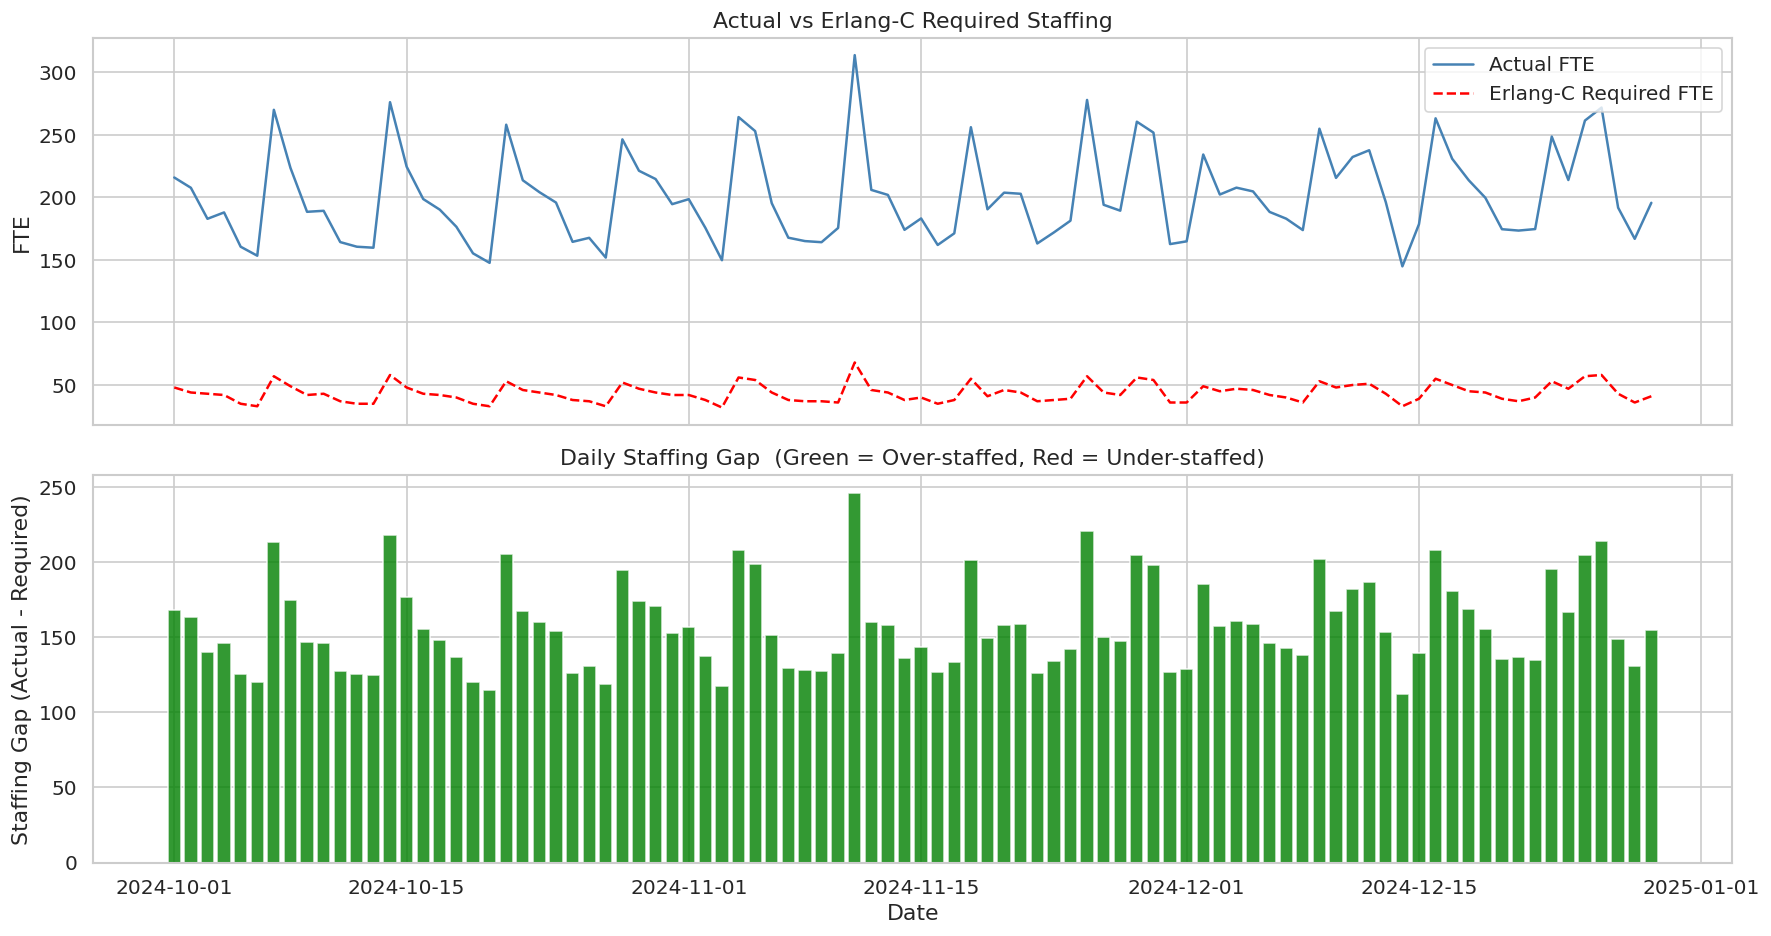


Staffing Gap Summary:
count     90.00
mean     157.23
std       29.47
min      111.80
25%      134.82
50%      151.90
75%      173.30
max      245.60
Name: staffing_gap, dtype: float64


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

axes[0].plot(sc_feat['date'], sc_feat['actualstaff_fte'], label='Actual FTE', color='steelblue')
axes[0].plot(sc_feat['date'], sc_feat['erlang_productive_fte'], label='Erlang-C Required FTE',
             color='red', linestyle='--')
axes[0].set_ylabel('FTE')
axes[0].set_title('Actual vs Erlang-C Required Staffing')
axes[0].legend()

colors = ['green' if g >= 0 else 'red' for g in sc_feat['staffing_gap']]
axes[1].bar(sc_feat['date'], sc_feat['staffing_gap'], color=colors, width=0.8, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_ylabel('Staffing Gap (Actual - Required)')
axes[1].set_title('Daily Staffing Gap  (Green = Over-staffed, Red = Under-staffed)')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

gap_summary = sc_feat['staffing_gap'].describe().round(2)
print("\nStaffing Gap Summary:")
print(gap_summary)


## IV. Forecasting Models

We train and evaluate three models:

| Model | Strengths in WFM context |
|---|---|
| **Prophet** | Automatic seasonality, holiday effects, interpretable components |
| **XGBoost** | Non-linear interactions, WFM features, handles spikes |
| **LightGBM** | Fast, handles categorical Region/Channel natively (Network model) |

### Evaluation Utilities

In [ ]:
def evaluate_forecast(y_true, y_pred, model_name='Model'):
    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mape  = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1))) * 100
    r2    = r2_score(y_true, y_pred)
    metrics = {'Model': model_name, 'MAE': round(mae,2), 'RMSE': round(rmse,2),
               'MAPE_%': round(mape,2), 'R2': round(r2,4)}
    return metrics


def plot_forecast(dates, y_true, y_pred, title, output_name):
    fig, axes = plt.subplots(2, 1, figsize=(15, 8))

    axes[0].plot(dates, y_true,  label='Actual', color='steelblue', linewidth=1.8)
    axes[0].plot(dates, y_pred, label='Forecast', color='red', linestyle='--', linewidth=1.8)
    axes[0].set_title(title)
    axes[0].set_ylabel('Offered Calls')
    axes[0].legend()

    residuals = y_true - y_pred
    axes[1].bar(dates, residuals, color=['green' if r >= 0 else 'red' for r in residuals],
                alpha=0.7, width=0.8)
    axes[1].axhline(0, color='black', linewidth=0.8)
    axes[1].set_title('Residuals (Actual − Forecast)')
    axes[1].set_ylabel('Residual')
    axes[1].set_xlabel('Date')

    plt.tight_layout()
    plt.show()


all_metrics = []  # Collect all model metrics for final comparison

### Data Splitting

In [ ]:
sc_feat_clean = sc_feat.dropna().reset_index(drop=True)
SPLIT_IDX = int(len(sc_feat_clean) * 0.80)

train = sc_feat_clean.iloc[:SPLIT_IDX].copy()
test  = sc_feat_clean.iloc[SPLIT_IDX:].copy()

print(f"Training rows: {len(train)}  ({train['date'].min().date()} → {train['date'].max().date()})")
print(f"Test rows:     {len(test)}   ({test['date'].min().date()} → {test['date'].max().date()})")

Training rows: 60  (2024-10-15 → 2024-12-13)
Test rows:     16   (2024-12-14 → 2024-12-29)


### Model 1 - Prophet

Prophet Metrics: {'Model': 'Prophet', 'MAE': 588.79, 'RMSE': np.float64(783.05), 'MAPE_%': np.float64(5.5), 'R2': 0.6551}


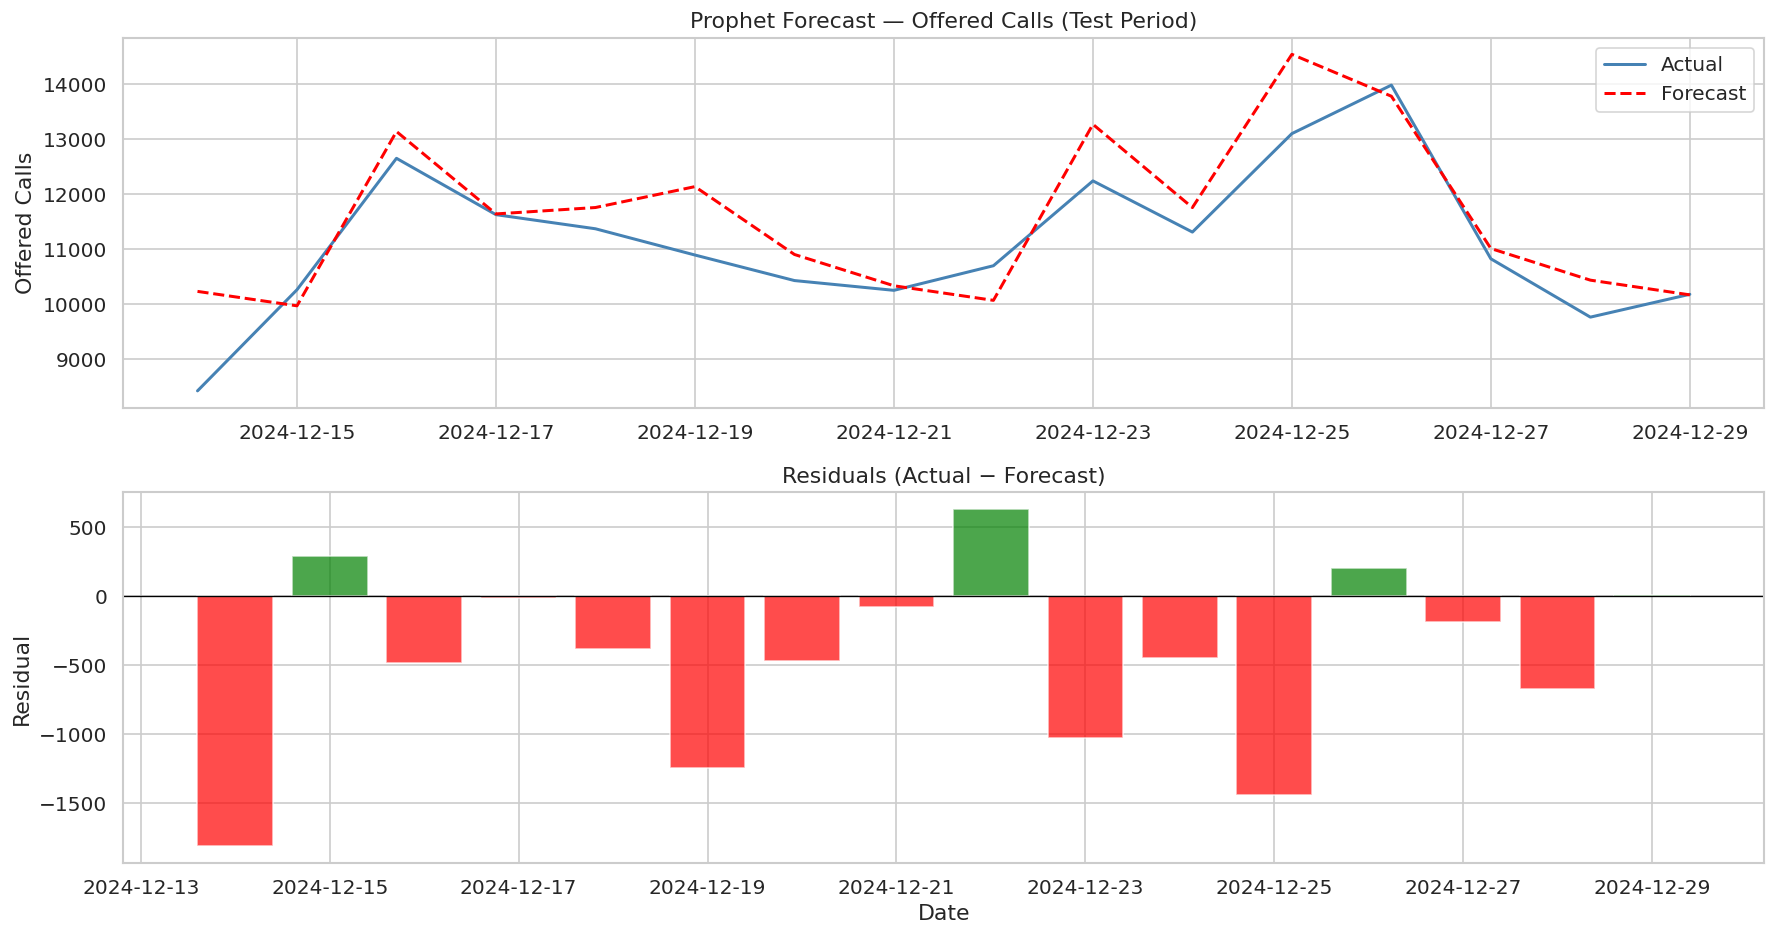

In [ ]:

# Prepare Prophet format (requires 'ds' and 'y')
prophet_train = train[['date','offered_calls','holidays','marketingevents']].rename(
    columns={'date':'ds','offered_calls':'y'}
)
prophet_test  = test[['date','offered_calls','holidays','marketingevents']].rename(
    columns={'date':'ds','offered_calls':'y'}
)

# Build custom holidays dataframe
holiday_dates = train.loc[train['holidays']==1,'date'].tolist() + \
                test.loc[test['holidays']==1,'date'].tolist()
holiday_df = pd.DataFrame({'holiday': 'public_holiday', 'ds': pd.to_datetime(holiday_dates)})

marketing_dates = train.loc[train['marketingevents']==1,'date'].tolist() + \
                  test.loc[test['marketingevents']==1,'date'].tolist()
marketing_df = pd.DataFrame({'holiday': 'marketing_event', 'ds': pd.to_datetime(marketing_dates)})

combined_holidays = pd.concat([holiday_df, marketing_df], ignore_index=True)

# Train Prophet
prophet_model = Prophet(
    yearly_seasonality=False,   # Only 90 days of data
    weekly_seasonality=True,
    daily_seasonality=False,
    holidays=combined_holidays,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.05,
    holidays_prior_scale=10.0,
    interval_width=0.95
)
prophet_model.fit(prophet_train)

# Predict on test
future_df        = prophet_model.make_future_dataframe(periods=len(test), freq='D')
prophet_forecast = prophet_model.predict(future_df)
prophet_test_pred = prophet_forecast.tail(len(test))['yhat'].values

# Evaluate
m_prophet = evaluate_forecast(test['offered_calls'].values, prophet_test_pred, 'Prophet')
all_metrics.append(m_prophet)
print("Prophet Metrics:", m_prophet)

plot_forecast(
    test['date'], test['offered_calls'], prophet_test_pred,
    'Prophet Forecast — Offered Calls (Test Period)', 'forecast_prophet'
)

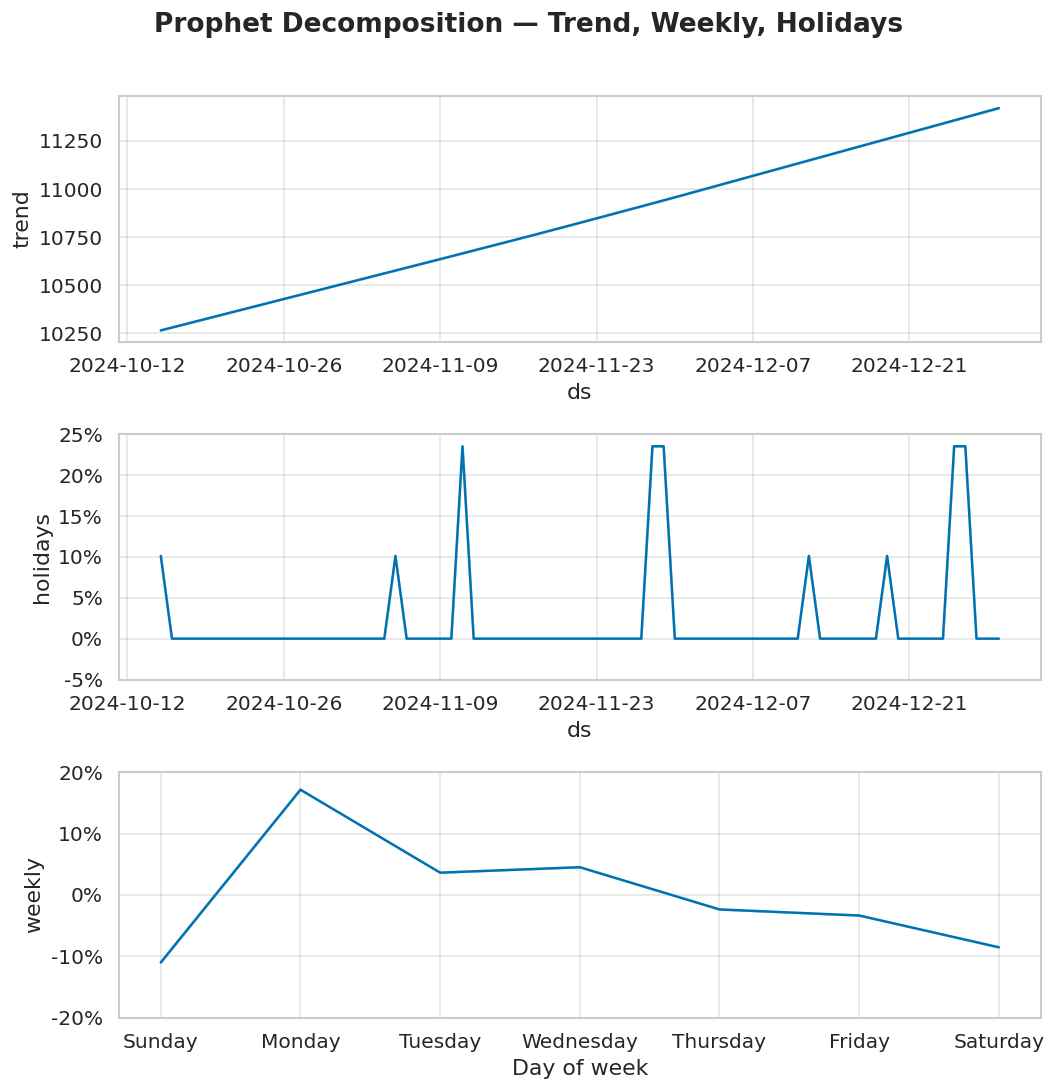

In [ ]:
# ── Prophet Component Plots ────────────────────────────────────────────────────
fig = prophet_model.plot_components(prophet_forecast)
plt.suptitle('Prophet Decomposition — Trend, Weekly, Holidays', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Model 2 - XGBoost

XGBoost Metrics: {'Model': 'XGBoost', 'MAE': 512.37, 'RMSE': np.float64(701.66), 'MAPE_%': np.float64(4.92), 'R2': 0.7231}


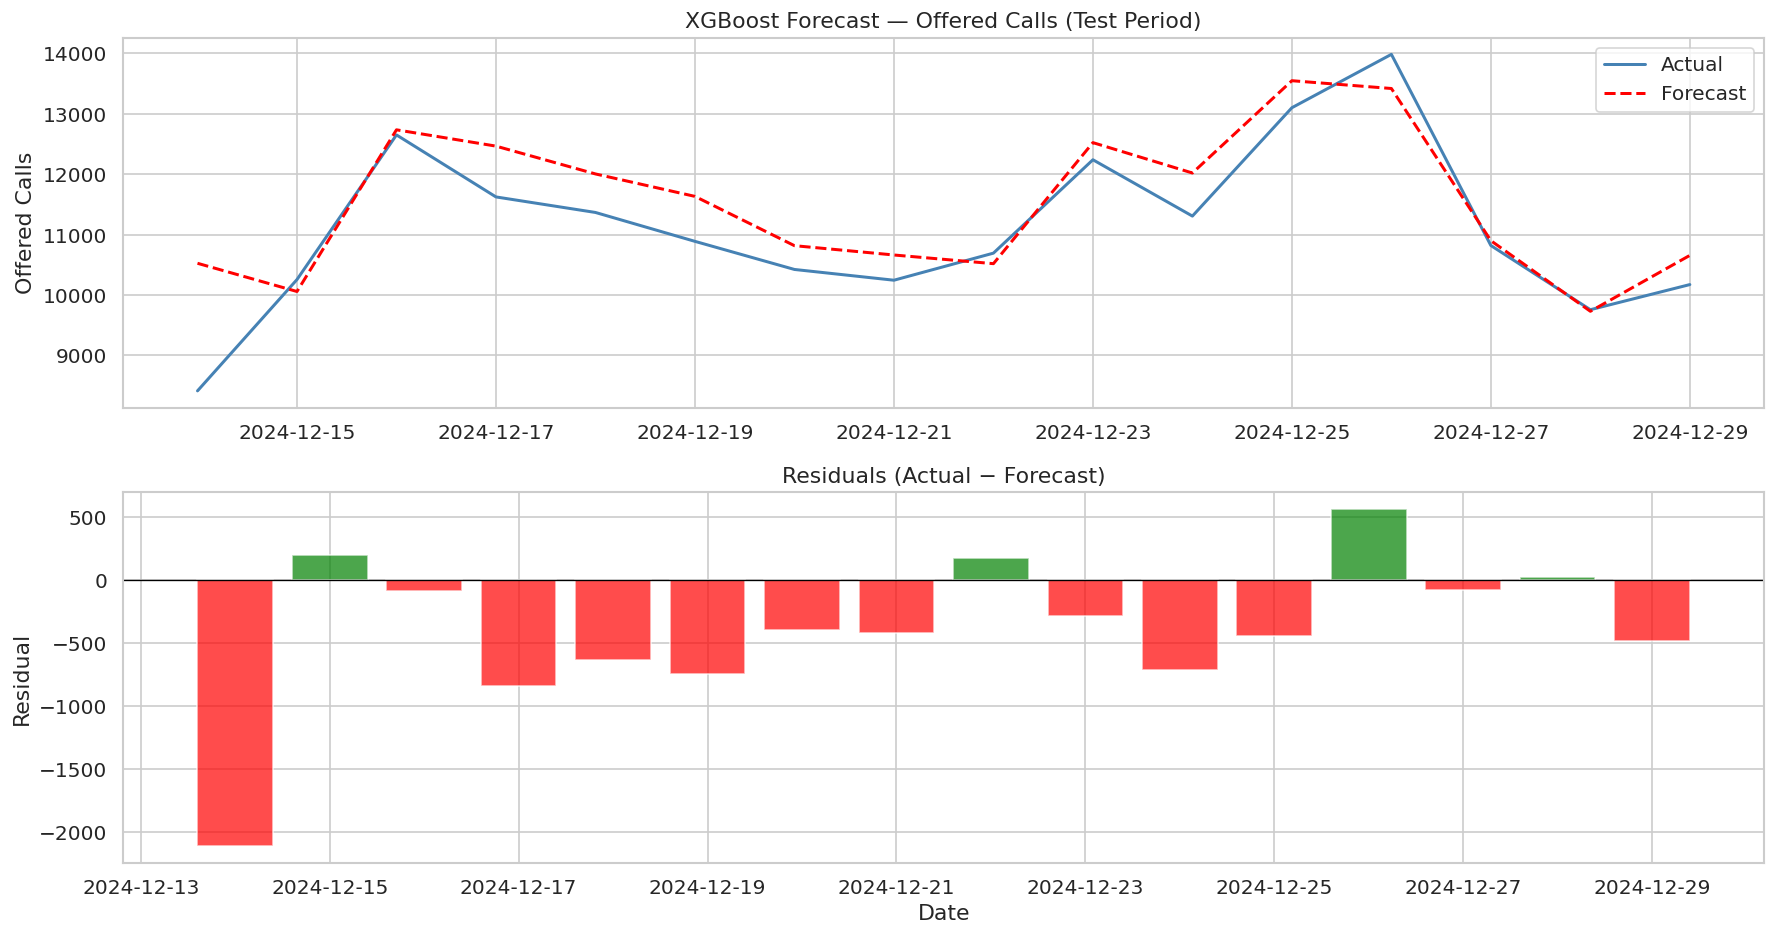

In [ ]:

FEATURE_COLS = [
    'day_of_week','day_of_year','week_of_year','month','is_weekend',
    'is_month_start','is_month_end','dow_sin','dow_cos','woy_sin','woy_cos',
    'holidays','marketingevents',
    'aht_s','shrinkage__','attrition___weekly_',
    'offered_calls_lag1','offered_calls_lag2','offered_calls_lag3',
    'offered_calls_lag7','offered_calls_lag14',
    'offered_calls_roll7_mean','offered_calls_roll7_std',
    'offered_calls_roll14_mean','offered_calls_roll14_std',
]
TARGET_COL = 'offered_calls'

# Filter to only existing columns
FEATURE_COLS = [c for c in FEATURE_COLS if c in sc_feat_clean.columns]

X_train = train[FEATURE_COLS]
y_train = train[TARGET_COL]
X_test  = test[FEATURE_COLS]
y_test  = test[TARGET_COL]

xgb_model = xgb.XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)

xgb_pred = xgb_model.predict(X_test)

m_xgb = evaluate_forecast(y_test.values, xgb_pred, 'XGBoost')
all_metrics.append(m_xgb)
print("XGBoost Metrics:", m_xgb)

plot_forecast(
    test['date'], y_test, xgb_pred,
    'XGBoost Forecast — Offered Calls (Test Period)', 'forecast_xgboost'
)

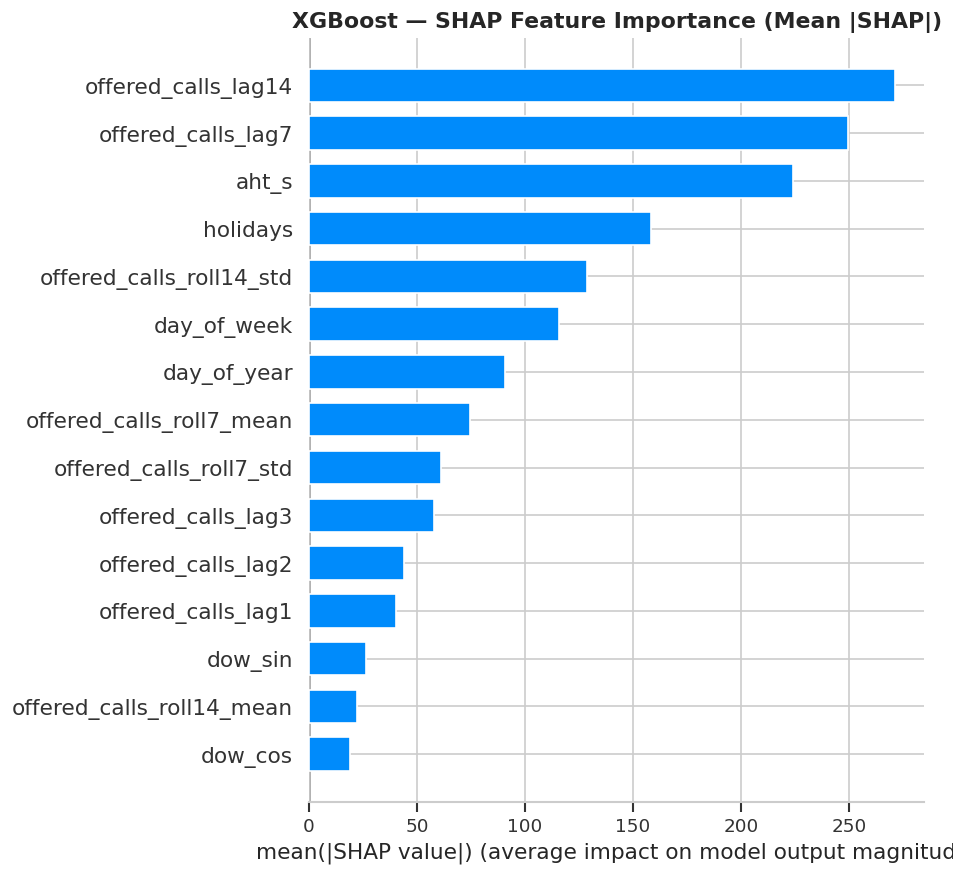

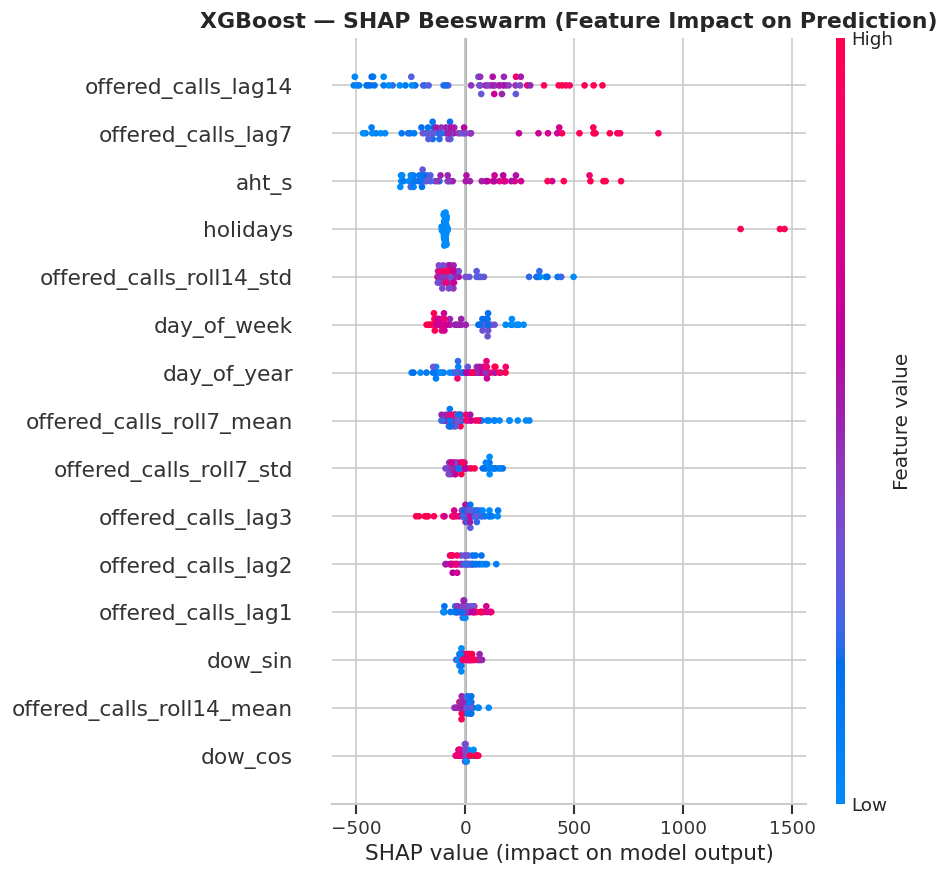

In [ ]:
# ── SHAP Feature Importance ────────────────────────────────────────────────────
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_train)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_train, plot_type='bar', show=False,
                  max_display=15)
plt.title('XGBoost — SHAP Feature Importance (Mean |SHAP|)', fontweight='bold')
plt.tight_layout()
plt.show()

# Beeswarm
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_train, show=False, max_display=15)
plt.title('XGBoost — SHAP Beeswarm (Feature Impact on Prediction)', fontweight='bold')
plt.tight_layout()
plt.show()

### Model 3 - LightGBM

In [ ]:

# Feature engineering for network data
net_feat = net.copy().sort_values(['region','channel','date']).reset_index(drop=True)
net_feat['day_of_week']  = net_feat['date'].dt.dayofweek
net_feat['week_of_year'] = net_feat['date'].dt.isocalendar().week.astype(int)
net_feat['month']        = net_feat['date'].dt.month
net_feat['is_weekend']   = (net_feat['day_of_week'] >= 5).astype(int)
net_feat['dow_sin'] = np.sin(2 * np.pi * net_feat['day_of_week'] / 7)
net_feat['dow_cos'] = np.cos(2 * np.pi * net_feat['day_of_week'] / 7)

# Lags within each Region-Channel group
grp = net_feat.groupby(['region','channel'])
for lag in [1, 7]:
    net_feat[f'offered_lag{lag}'] = grp['offered'].shift(lag)
net_feat['offered_roll7_mean'] = grp['offered'].shift(1).transform(
    lambda x: x.rolling(7, min_periods=3).mean()
)

# Label-encode categoricals
net_feat['region_enc']  = net_feat['region'].astype('category').cat.codes
net_feat['channel_enc'] = net_feat['channel'].astype('category').cat.codes

NET_FEATURES = [
    'region_enc','channel_enc',
    'day_of_week','week_of_year','month','is_weekend','dow_sin','dow_cos',
    'holidayregion','aht_s','shrinkage__','attrition___weekly_',
    'offered_lag1','offered_lag7','offered_roll7_mean'
]
NET_FEATURES = [c for c in NET_FEATURES if c in net_feat.columns]

net_clean  = net_feat.dropna(subset=NET_FEATURES+['offered']).reset_index(drop=True)
split_date = net_clean['date'].quantile(0.80, interpolation='nearest')

net_train = net_clean[net_clean['date'] <= split_date]
net_test  = net_clean[net_clean['date'] >  split_date]

lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=10,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.05,
    reg_lambda=0.5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)
lgb_model.fit(
    net_train[NET_FEATURES], net_train['offered'],
    eval_set=[(net_test[NET_FEATURES], net_test['offered'])],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)]
)

net_pred = lgb_model.predict(net_test[NET_FEATURES])
m_lgb = evaluate_forecast(net_test['offered'].values, net_pred, 'LightGBM (Network)')
all_metrics.append(m_lgb)
print("LightGBM Network Metrics:", m_lgb)

LightGBM Network Metrics: {'Model': 'LightGBM (Network)', 'MAE': 133.32, 'RMSE': np.float64(185.83), 'MAPE_%': np.float64(6.15), 'R2': 0.9743}


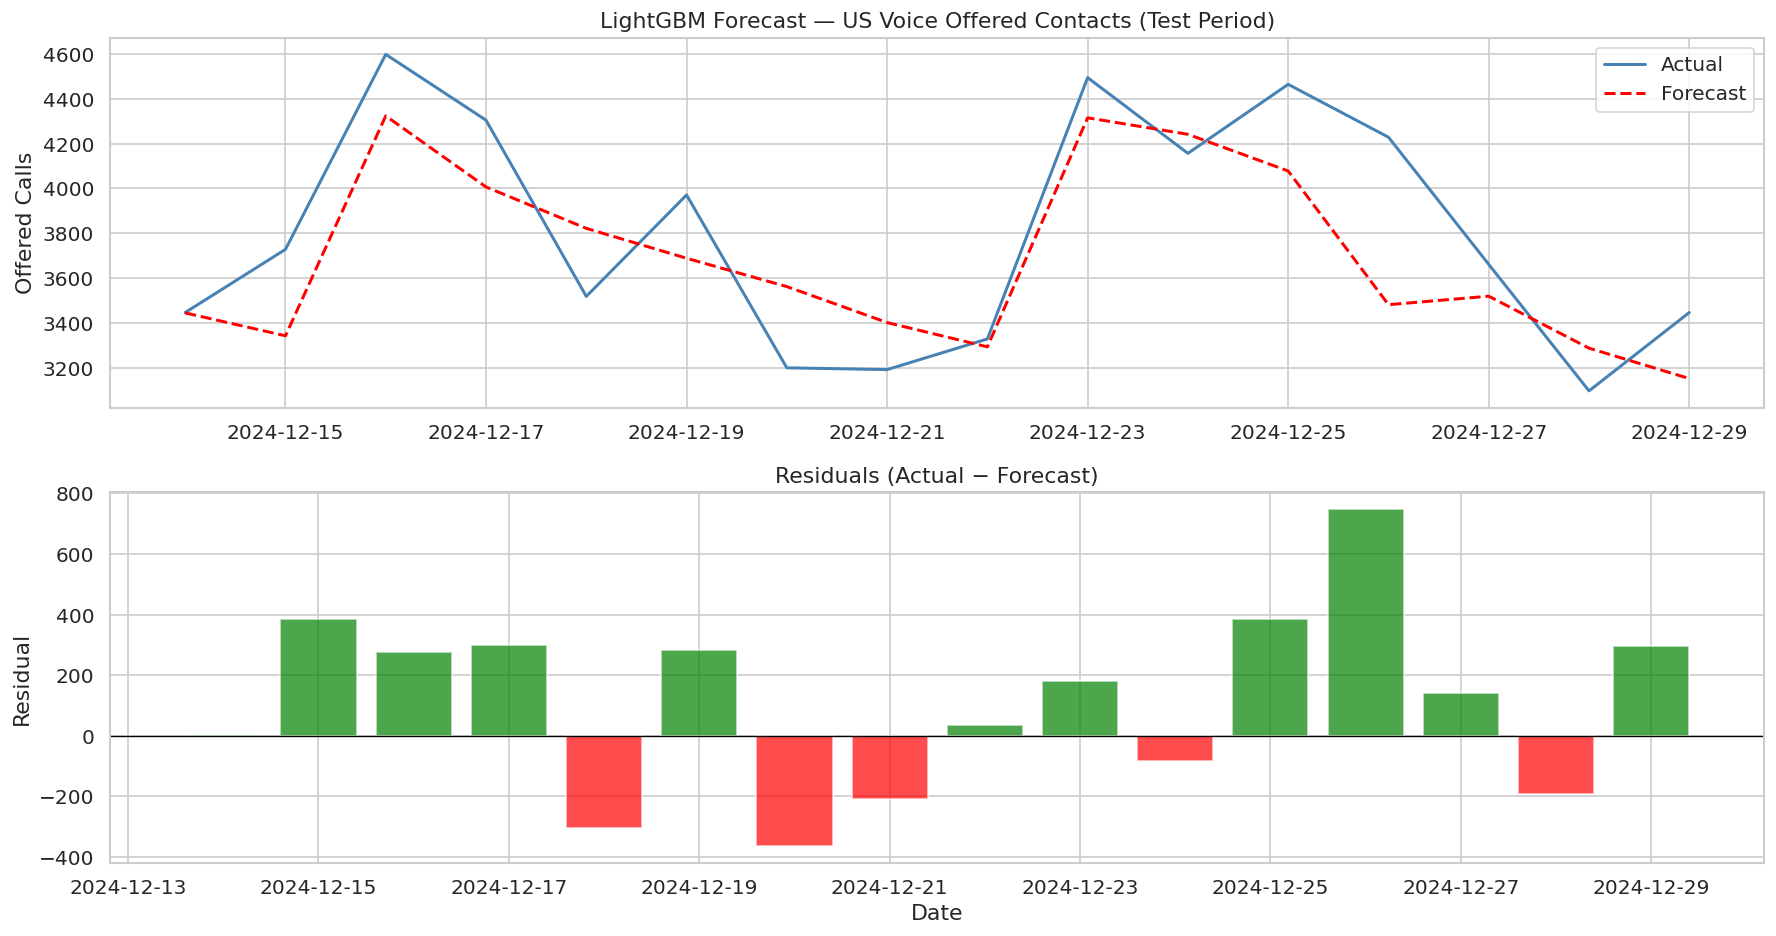

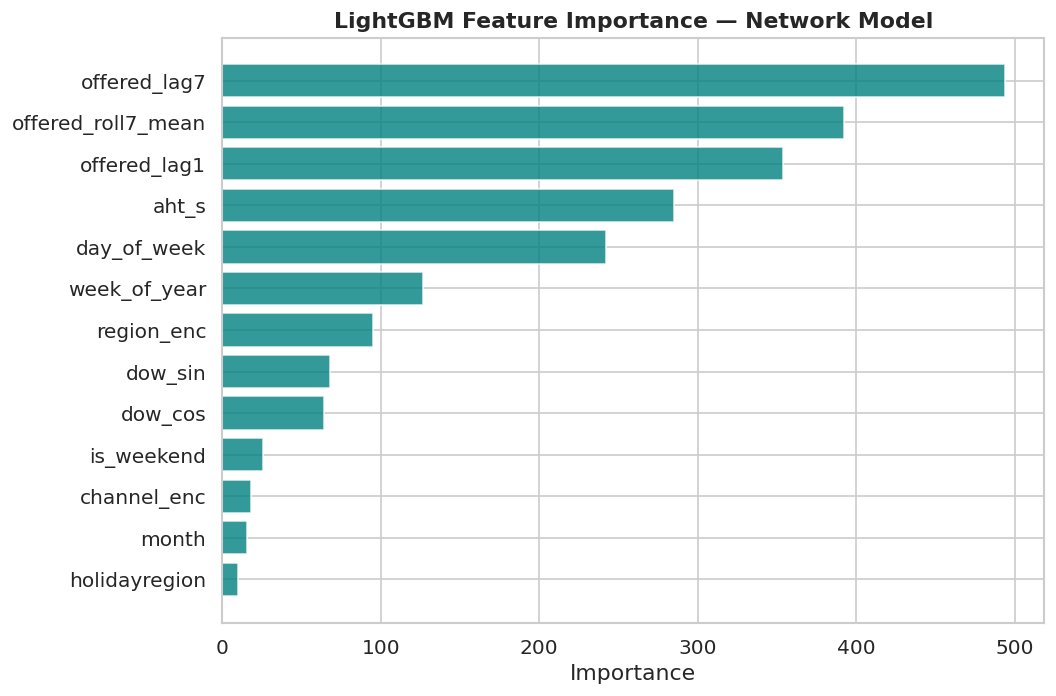

In [ ]:
# ── Network forecast: US Voice as example ─────────────────────────────────────
mask = (net_test['region']=='US') & (net_test['channel']=='Voice')
us_voice_test = net_test[mask].copy()
us_voice_pred = lgb_model.predict(us_voice_test[NET_FEATURES])

plot_forecast(
    us_voice_test['date'].values,
    us_voice_test['offered'].values,
    us_voice_pred,
    'LightGBM Forecast — US Voice Offered Contacts (Test Period)',
    'forecast_lgbm_us_voice'
)

# LightGBM feature importance
lgb_imp = pd.DataFrame({
    'Feature': NET_FEATURES,
    'Importance': lgb_model.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(lgb_imp['Feature'], lgb_imp['Importance'], color='teal', alpha=0.8)
ax.set_title('LightGBM Feature Importance — Network Model', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()


## V. Model Comparison & Diagnostics

### Metric Comparison

,MAE,RMSE,MAPE_%,R2
Model,,,,
Prophet,589,783,5.50%,0.6551
XGBoost,512,702,4.92%,0.7231
LightGBM (Network),133,186,6.15%,0.9743


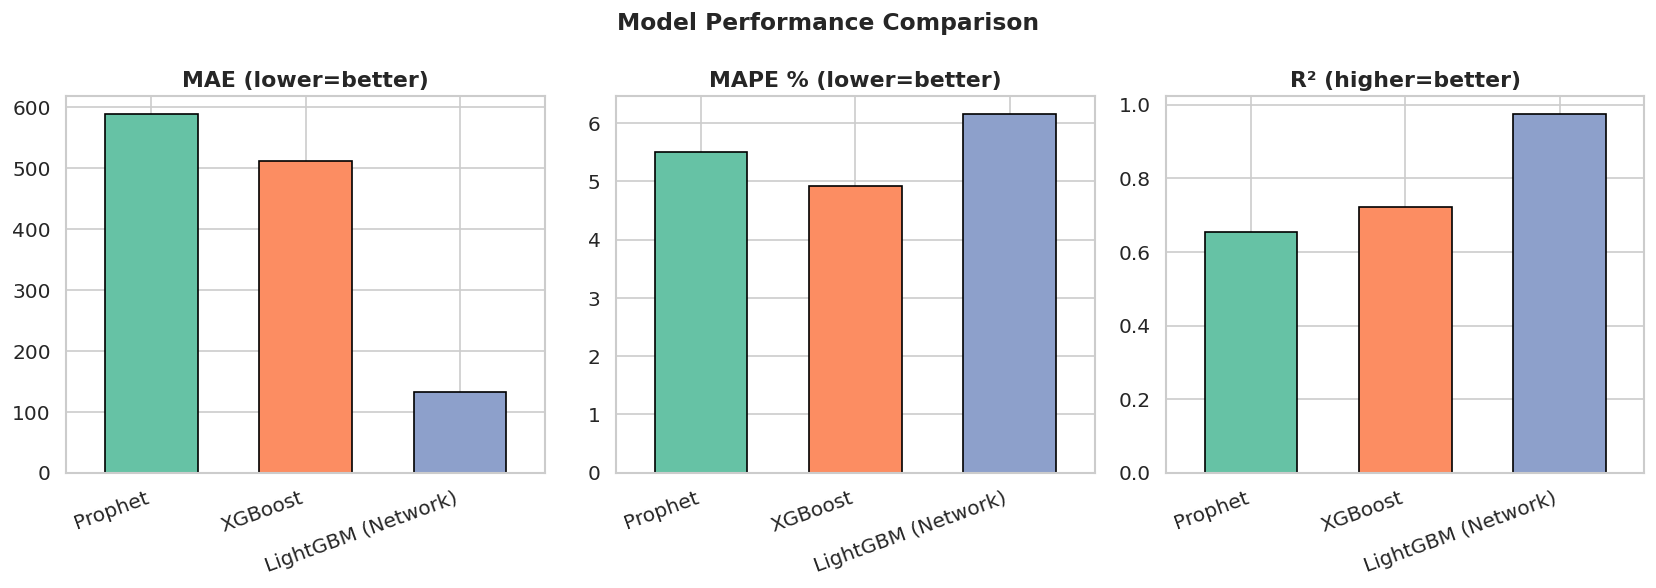

In [ ]:
# ── Side-by-side metrics table ─────────────────────────────────────────────────
metrics_df = pd.DataFrame(all_metrics).set_index('Model')

display(HTML("<h3>📋 Model Performance Comparison</h3>"))
display(metrics_df.style
    .background_gradient(subset=['MAE','RMSE','MAPE_%'], cmap='RdYlGn_r')
    .background_gradient(subset=['R2'], cmap='RdYlGn')
    .format({'MAE':'{:,.0f}','RMSE':'{:,.0f}','MAPE_%':'{:.2f}%','R2':'{:.4f}'})
)

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col, label in zip(axes, ['MAE','MAPE_%','R2'],
                           ['MAE (lower=better)','MAPE % (lower=better)','R² (higher=better)']):
    bar_colors = sns.color_palette('Set2', len(metrics_df))
    metrics_df[col].plot.bar(ax=ax, color=bar_colors, edgecolor='black', width=0.6)
    ax.set_title(label, fontweight='bold')
    ax.set_xticklabels(metrics_df.index, rotation=20, ha='right')
    ax.set_xlabel('')

plt.suptitle('Model Performance Comparison', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

### Cross Validation Backtesting

In [ ]:

print("Running 3-fold walk-forward CV on XGBoost...")

tscv = TimeSeriesSplit(n_splits=3, gap=0)
cv_results = []

for fold, (tr_idx, te_idx) in enumerate(tscv.split(sc_feat_clean), 1):
    X_tr = sc_feat_clean.iloc[tr_idx][FEATURE_COLS]
    y_tr = sc_feat_clean.iloc[tr_idx][TARGET_COL]
    X_te = sc_feat_clean.iloc[te_idx][FEATURE_COLS]
    y_te = sc_feat_clean.iloc[te_idx][TARGET_COL]

    m = xgb.XGBRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE,
        verbosity=0, n_jobs=-1
    )
    m.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)
    preds = m.predict(X_te)
    metrics = evaluate_forecast(y_te.values, preds, f'XGB Fold {fold}')
    cv_results.append(metrics)
    print(f"  Fold {fold} — MAE: {metrics['MAE']:,.0f}  MAPE: {metrics['MAPE_%']:.2f}%  R²: {metrics['R2']:.4f}")

cv_df = pd.DataFrame(cv_results)
print("\nCV Summary:")
display(cv_df[['Model','MAE','RMSE','MAPE_%','R2']].describe().round(3))

Running 3-fold walk-forward CV on XGBoost...
  Fold 1 — MAE: 562  MAPE: 5.01%  R²: 0.6877
  Fold 2 — MAE: 625  MAPE: 5.36%  R²: 0.4970
  Fold 3 — MAE: 428  MAPE: 4.01%  R²: 0.7749

CV Summary:


,MAE,RMSE,MAPE_%,R2
count,3.000,3.000,3.000,3.000
mean,538.647,746.997,4.793,0.653
std,100.461,123.158,0.701,0.142
min,428.450,605.460,4.010,0.497
25%,495.405,705.625,4.510,0.592
50%,562.360,805.790,5.010,0.688
75%,593.745,817.765,5.185,0.731
max,625.130,829.740,5.360,0.775



## VI. Staffing Recommendations & Headcount Planning

### Erlang Computation Based on Forecasted Calls

In [ ]:
test_staffing = test[['date','aht_s','shrinkage','actualstaff_fte','servicelevel']].copy()
test_staffing['forecast_calls']    = xgb_pred.round(0).astype(int)
test_staffing['actual_calls']      = y_test.values

def compute_erlang_row(row, sl=0.80):
    p, s, e, pw = required_fte_erlang(
        offered_calls=row['forecast_calls'],
        aht_s=row['aht_s'],
        shrinkage_pct=row['shrinkage'],
        target_sl=sl
    )
    return pd.Series({'req_productive_fte': p, 'req_scheduled_fte': s, 'erlangs': e})

erlang_cols = test_staffing.apply(compute_erlang_row, axis=1)
test_staffing = pd.concat([test_staffing, erlang_cols], axis=1)
test_staffing['overstaffing_gap']  = test_staffing['actualstaff_fte'] - test_staffing['req_productive_fte']
test_staffing['recommended_hires'] = np.maximum(
    0, test_staffing['req_scheduled_fte'] - test_staffing['actualstaff_fte']
).round(1)

print("\n── Staffing Plan (Test Period Sample) ──")
display(test_staffing[[
    'date','forecast_calls','req_productive_fte','req_scheduled_fte',
    'actualstaff_fte','overstaffing_gap','recommended_hires'
]].head(10))

total_hire_needed = test_staffing['recommended_hires'].sum()
avg_gap           = test_staffing['overstaffing_gap'].mean()
print(f"\n📌 Total FTE-days of under-staffing: {total_hire_needed}")
print(f"📌 Average daily staffing gap:       {avg_gap:.1f} FTE  "
      f"({'Over' if avg_gap >= 0 else 'Under'}-staffed on average)")


── Staffing Plan (Test Period Sample) ──


,date,forecast_calls,req_productive_fte,req_scheduled_fte,actualstaff_fte,overstaffing_gap,recommended_hires
60,2024-12-14,10524,40.0,55.95,144.8,104.8,0.0
61,2024-12-15,10057,38.0,54.07,178.5,140.5,0.0
62,2024-12-16,12732,56.0,81.88,263.1,207.1,0.0
63,2024-12-17,12463,53.0,74.00,230.8,177.8,0.0
64,2024-12-18,12002,48.0,67.42,213.6,165.6,0.0
65,2024-12-19,11631,46.0,64.86,199.6,153.6,0.0
66,2024-12-20,10816,40.0,55.06,174.5,134.5,0.0
67,2024-12-21,10661,39.0,55.57,173.4,134.4,0.0
68,2024-12-22,10518,39.0,53.59,174.6,135.6,0.0
69,2024-12-23,12520,54.0,76.61,248.5,194.5,0.0



📌 Total FTE-days of under-staffing: 0.0
📌 Average daily staffing gap:       160.2 FTE  (Over-staffed on average)


### Staffing Dashboard

In [ ]:

fig = make_subplots(rows=2, cols=2,
    subplot_titles=[
        'Forecasted vs Actual Calls',
        'Required vs Actual FTE',
        'Daily Recommended Hires (FTE)',
        'Staffing Gap Distribution'
    ],
    shared_xaxes=False
)

# Panel 1
fig.add_trace(go.Scatter(x=test_staffing['date'], y=test_staffing['actual_calls'],
    name='Actual Calls', line=dict(color='steelblue')), row=1, col=1)
fig.add_trace(go.Scatter(x=test_staffing['date'], y=test_staffing['forecast_calls'],
    name='Forecast Calls', line=dict(color='red', dash='dash')), row=1, col=1)

# Panel 2
fig.add_trace(go.Scatter(x=test_staffing['date'], y=test_staffing['req_productive_fte'],
    name='Required FTE (Erlang-C)', line=dict(color='orange')), row=1, col=2)
fig.add_trace(go.Scatter(x=test_staffing['date'], y=test_staffing['actualstaff_fte'],
    name='Actual FTE', line=dict(color='green')), row=1, col=2)

# Panel 3
fig.add_trace(go.Bar(x=test_staffing['date'], y=test_staffing['recommended_hires'],
    name='Recommended Hires', marker_color='firebrick'), row=2, col=1)

# Panel 4
fig.add_trace(go.Histogram(x=test_staffing['overstaffing_gap'], nbinsx=15,
    name='Gap Distribution', marker_color='slategray'), row=2, col=2)

fig.update_layout(
    title_text='WFM Staffing Dashboard — Test Period',
    height=700, showlegend=True
)
fig.show()


## VII. 30-Day Forward Forecast

### Feature building

In [ ]:

HORIZON = 30
last_date = sc_feat_clean['date'].max()

future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=HORIZON, freq='D')
future_df    = pd.DataFrame({'date': future_dates})

# Calendar features
future_df['day_of_week']    = future_df['date'].dt.dayofweek
future_df['day_of_year']    = future_df['date'].dt.dayofyear
future_df['week_of_year']   = future_df['date'].dt.isocalendar().week.astype(int)
future_df['month']          = future_df['date'].dt.month
future_df['is_weekend']     = (future_df['day_of_week'] >= 5).astype(int)
future_df['is_month_start'] = future_df['date'].dt.is_month_start.astype(int)
future_df['is_month_end']   = future_df['date'].dt.is_month_end.astype(int)
future_df['dow_sin']        = np.sin(2 * np.pi * future_df['day_of_week'] / 7)
future_df['dow_cos']        = np.cos(2 * np.pi * future_df['day_of_week'] / 7)
future_df['woy_sin']        = np.sin(2 * np.pi * future_df['week_of_year'] / 52)
future_df['woy_cos']        = np.cos(2 * np.pi * future_df['week_of_year'] / 52)

# Assume no holidays or marketing events (can be manually overridden)
future_df['holidays']       = 0
future_df['marketingevents']= 0

# Use trailing averages for operational features
future_df['aht_s']               = sc_feat_clean['aht_s'].tail(14).mean().round(1)
future_df['shrinkage']         = sc_feat_clean['shrinkage'].tail(14).mean().round(2)
future_df['attrition_weekly'] = sc_feat_clean['attrition_weekly'].tail(4).mean().round(3)

# Recursive lag filling using last known values + rolling window
hist_calls = sc_feat_clean['offered_calls'].tolist()
future_calls = []

for i in range(HORIZON):
    all_calls = hist_calls + future_calls  # growing buffer
    row = future_df.iloc[[i]].copy()
    for lag in [1, 2, 3, 7, 14]:
        idx = len(all_calls) - lag
        row[f'offered_calls_lag{lag}'] = all_calls[idx] if idx >= 0 else np.nan
    for win in [7, 14]:
        buf = all_calls[-win:]
        row[f'offered_calls_roll{win}_mean'] = np.mean(buf) if buf else np.nan
        row[f'offered_calls_roll{win}_std']  = np.std(buf)  if len(buf) > 1 else 0

    row_feat = row[FEATURE_COLS].fillna(method='bfill').fillna(method='ffill')
    pred_val = xgb_model.predict(row_feat)[0]
    future_calls.append(max(0, pred_val))

future_df['forecast_calls'] = np.round(future_calls).astype(int)

# Compute required FTE for the forecast
erlang_future = future_df.apply(lambda r: required_fte_erlang(
    r['forecast_calls'], r['aht_s'], r['shrinkage']
), axis=1, result_type='expand')
erlang_future.columns = ['req_productive_fte','req_scheduled_fte','erlangs','pw_wait']
future_df = pd.concat([future_df, erlang_future], axis=1)

print("30-Day Forward Forecast:")
display(future_df[['date','day_of_week','forecast_calls',
                    'req_productive_fte','req_scheduled_fte']].to_string(index=False))

30-Day Forward Forecast:


'      date  day_of_week  forecast_calls  req_productive_fte  req_scheduled_fte\n2024-12-30            0           12296                49.0              68.91\n2024-12-31            1           11768                47.0              66.09\n2025-01-01            2           12123                49.0              68.91\n2025-01-02            3           11768                47.0              66.09\n2025-01-03            4           11511                46.0              64.69\n2025-01-04            5           10876                44.0              61.88\n2025-01-05            6           11060                45.0              63.28\n2025-01-06            0           12192                49.0              68.91\n2025-01-07            1           11891                48.0              67.50\n2025-01-08            2           12295                49.0              68.91\n2025-01-09            3           12229                49.0              68.91\n2025-01-10            4           11510

### 30-day forecast Visualization

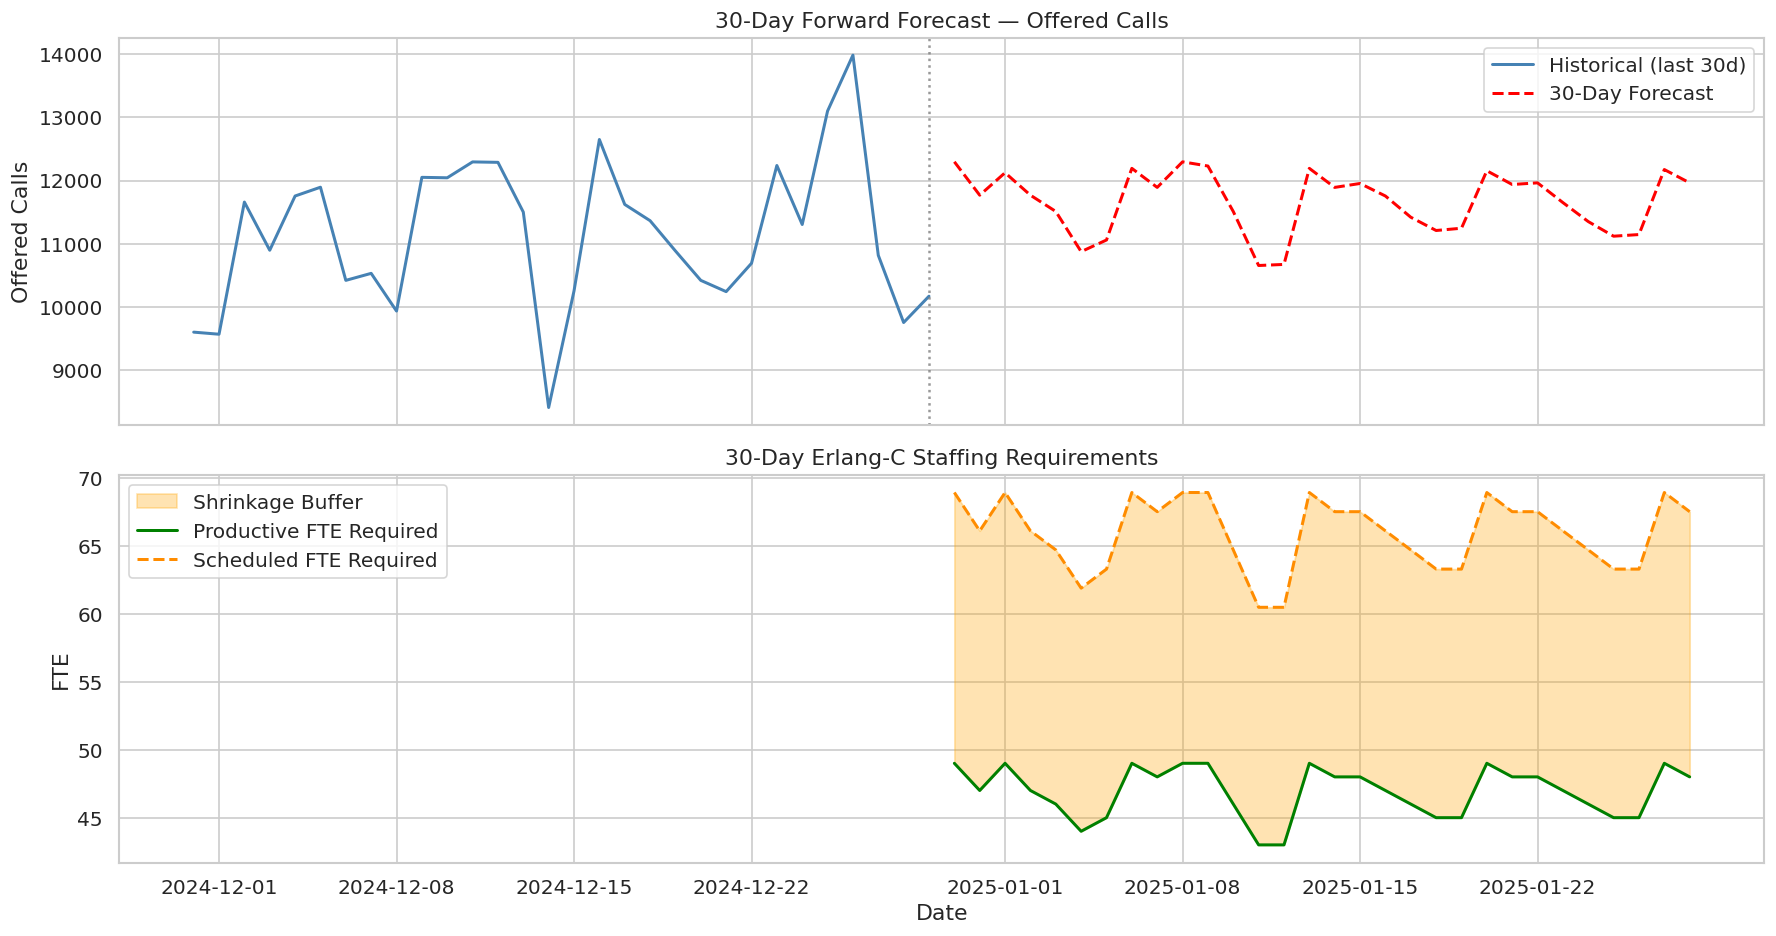

In [ ]:

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Historical + forecast
hist_plot = sc_feat_clean[['date','offered_calls']].tail(30)
axes[0].plot(hist_plot['date'], hist_plot['offered_calls'],
             label='Historical (last 30d)', color='steelblue', linewidth=1.8)
axes[0].plot(future_df['date'], future_df['forecast_calls'],
             label='30-Day Forecast', color='red', linestyle='--', linewidth=1.8)
axes[0].axvline(x=last_date, color='gray', linestyle=':', alpha=0.8)
axes[0].set_ylabel('Offered Calls')
axes[0].set_title('30-Day Forward Forecast — Offered Calls')
axes[0].legend()

axes[1].fill_between(future_df['date'],
                     future_df['req_productive_fte'],
                     future_df['req_scheduled_fte'],
                     alpha=0.3, color='orange', label='Shrinkage Buffer')
axes[1].plot(future_df['date'], future_df['req_productive_fte'],
             color='green', label='Productive FTE Required', linewidth=1.8)
axes[1].plot(future_df['date'], future_df['req_scheduled_fte'],
             color='darkorange', linestyle='--', label='Scheduled FTE Required', linewidth=1.8)
axes[1].set_ylabel('FTE')
axes[1].set_title('30-Day Erlang-C Staffing Requirements')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.tight_layout()
plt.show()

### Unzoomed

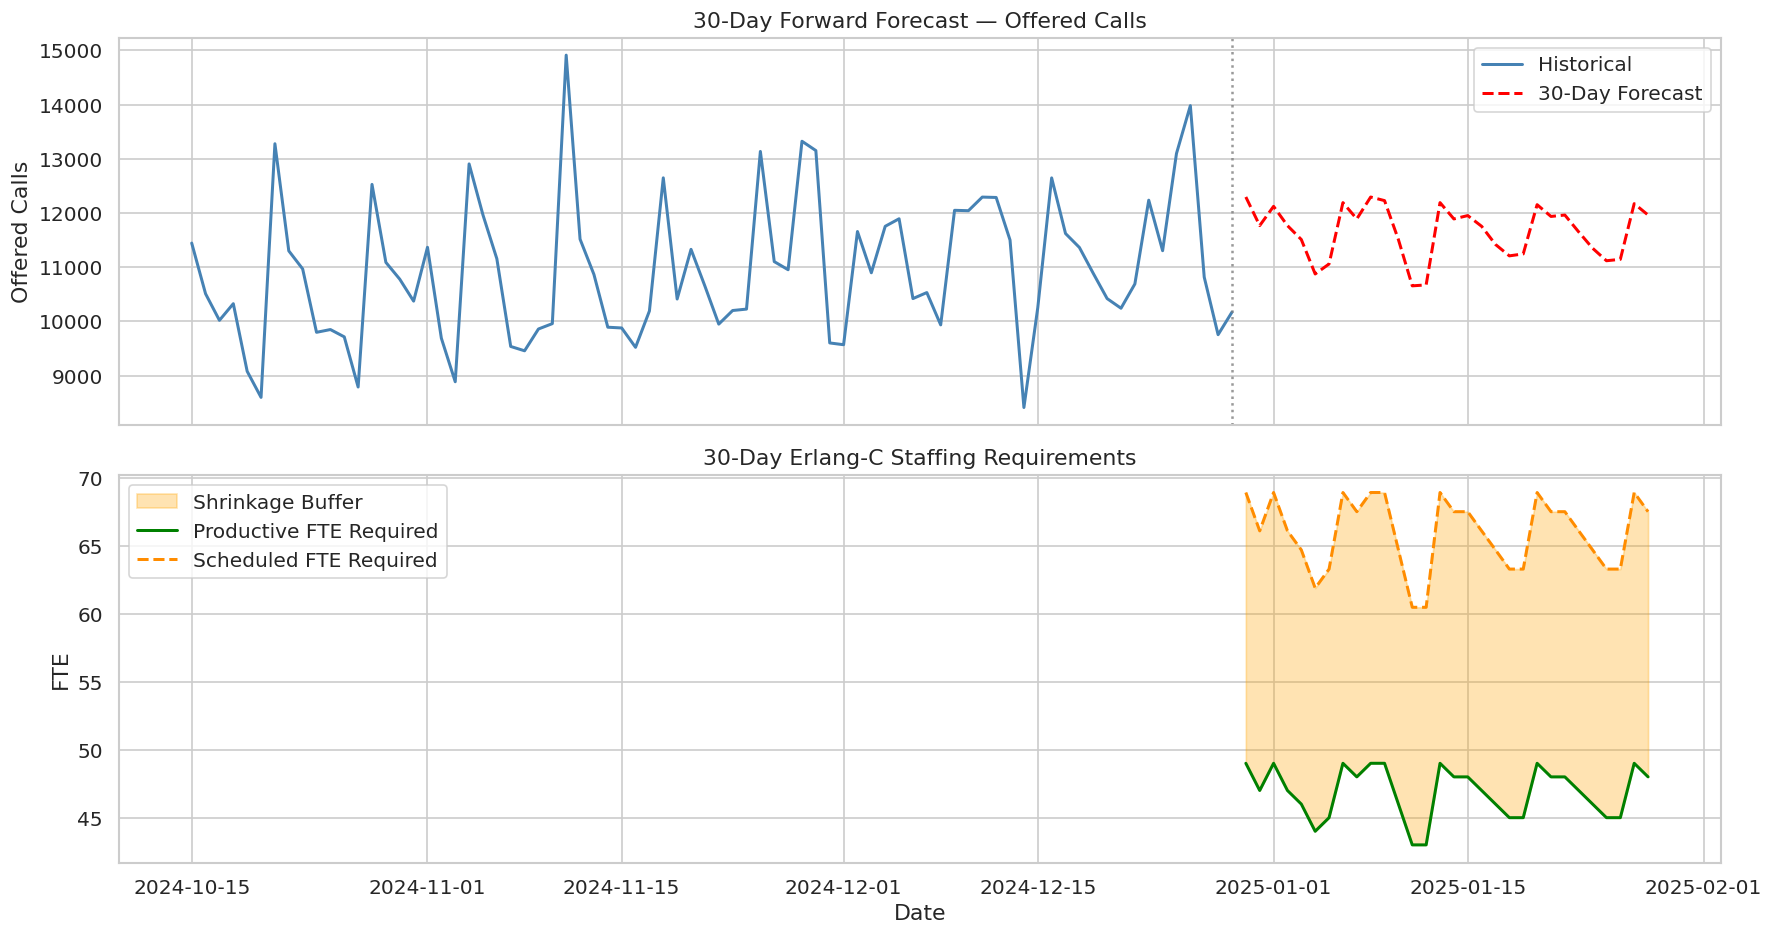

In [ ]:

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Historical + forecast
hist_plot = sc_feat_clean[['date','offered_calls']]
axes[0].plot(hist_plot['date'], hist_plot['offered_calls'],
             label='Historical', color='steelblue', linewidth=1.8)
axes[0].plot(future_df['date'], future_df['forecast_calls'],
             label='30-Day Forecast', color='red', linestyle='--', linewidth=1.8)
axes[0].axvline(x=last_date, color='gray', linestyle=':', alpha=0.8)
axes[0].set_ylabel('Offered Calls')
axes[0].set_title('30-Day Forward Forecast — Offered Calls')
axes[0].legend()

axes[1].fill_between(future_df['date'],
                     future_df['req_productive_fte'],
                     future_df['req_scheduled_fte'],
                     alpha=0.3, color='orange', label='Shrinkage Buffer')
axes[1].plot(future_df['date'], future_df['req_productive_fte'],
             color='green', label='Productive FTE Required', linewidth=1.8)
axes[1].plot(future_df['date'], future_df['req_scheduled_fte'],
             color='darkorange', linestyle='--', label='Scheduled FTE Required', linewidth=1.8)
axes[1].set_ylabel('FTE')
axes[1].set_title('30-Day Erlang-C Staffing Requirements')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.tight_layout()
plt.show()


## VIII. Export Results

In [ ]:
import os

OUTPUT_DIR = os.path.join(os.path.dirname(DATASET_PATH), 'WFM_Pipeline_Outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)
export_path = os.path.join(OUTPUT_DIR, 'WFM_Forecast_Results.xlsx')

with pd.ExcelWriter(export_path, engine='openpyxl') as writer:

    # Sheet 1: Model metrics
    metrics_df.reset_index().to_excel(writer, sheet_name='Model_Metrics', index=False)

    # Sheet 2: Single-centre test predictions
    test_export = test[['date','offered_calls']].copy()
    test_export['xgb_forecast']   = xgb_pred.round(0).astype(int)
    test_export['prophet_forecast'] = prophet_test_pred.round(0).astype(int)
    test_export.to_excel(writer, sheet_name='SC_Test_Predictions', index=False)

    # Sheet 3: Staffing plan
    test_staffing.to_excel(writer, sheet_name='Staffing_Plan_Test', index=False)

    # Sheet 4: 30-day forward forecast
    future_df[['date','forecast_calls','req_productive_fte','req_scheduled_fte',
               'erlangs','pw_wait']].to_excel(writer, sheet_name='30Day_Forward_Forecast', index=False)

    # Sheet 5: Network test predictions
    net_out = net_test[['date','region','channel','offered']].copy()
    net_out['lgbm_forecast'] = net_pred.round(0).astype(int)
    net_out.to_excel(writer, sheet_name='Network_Test_Predictions', index=False)

print(f"✅ Results exported to: {export_path}")

✅ Results exported to: /content/WFM_Pipeline_Outputs/WFM_Forecast_Results.xlsx


### Final Pipeline Summary

In [ ]:

display(HTML("""
<div style='background:#7d32bf;padding:20px;border-radius:10px;border-left:5px solid #3366cc'>
  <h2> Pipeline Complete — Summary</h2>
  <table style='width:100%;border-collapse:collapse'>
    <tr style='background:#dce8ff'>
      <th style='padding:8px;text-align:left'>Component</th>
      <th style='padding:8px;text-align:left'>Details</th>
    </tr>
    <tr><td style='padding:8px'> Dataset</td>
        <td style='padding:8px'>Q4 2024 90 days, Single Centre + 6 Region-Channel streams</td></tr>
    <tr><td style='padding:8px'> Features</td>
        <td style='padding:8px'>Calendar, lag/rolling, Erlang-C staffing, WFM metrics (utilisation, gap)</td></tr>
    <tr><td style='padding:8px'> Models Trained</td>
        <td style='padding:8px'>Prophet (baseline) · XGBoost (SC) · LightGBM (Network)</td></tr>
    <tr><td style='padding:8px'> Staffing Engine</td>
        <td style='padding:8px'>Erlang-C iterative solver with shrinkage inflation</td></tr>
    <tr><td style='padding:8px'> Forward Forecast</td>
        <td style='padding:8px'>30-day recursive call volume + required FTE plan</td></tr>
    <tr><td style='padding:8px'> Outputs</td>
        <td style='padding:8px'>Excel workbook (5 sheets) saved to Google Drive — all charts displayed inline</td></tr>
  </table>
</div>
"""))

print(" Pipeline complete — all charts rendered inline above.")

Component,Details
Dataset,"Q4 2024 90 days, Single Centre + 6 Region-Channel streams"
Features,"Calendar, lag/rolling, Erlang-C staffing, WFM metrics (utilisation, gap)"
Models Trained,Prophet (baseline) · XGBoost (SC) · LightGBM (Network)
Staffing Engine,Erlang-C iterative solver with shrinkage inflation
Forward Forecast,30-day recursive call volume + required FTE plan
Outputs,Excel workbook (5 sheets) saved to Google Drive — all charts displayed inline


 Pipeline complete — all charts rendered inline above.
